# Portfolio: Combining Three Signals

Each of the preceding notebooks evaluated a single signal in isolation. This notebook combines them into one portfolio and asks the questions that only make sense at the portfolio level: how correlated are the signals with each other, what does the combined return distribution look like, where does the tail risk live, and does the combination survive walk-forward evaluation across multiple regimes.


## Updated methodology

Numbers in this notebook differ from earlier versions: point-in-time membership masking, an `exec_lag=2` execution model, and Deflated Sharpe reporting are now applied. Previous combined-portfolio Sharpe: **-0.399**; previous walk-forward mean Sharpe across 16 windows: **-0.37**.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from helper import (
    Optimizer, port_ret, quick_weights, stats, ic,
    dist_plot, var_cvar, walk_forward_splits,
)

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)


## Load Signals and Weights

Run the three signal notebooks first; each one persists its in-sample and out-of-sample weights along with the raw signal panel.


In [2]:
raw = pd.read_parquet('../data/sp500.parquet')
close = raw['Close']
returns = close.pct_change()
spy = pd.read_parquet('../data/spy.parquet')['Close'].squeeze().pct_change()

IS_END = '2020-12-31'

names = ['01_mean_reversion', '02_momentum', '03_low_volatility']
labels = ['MeanRev', 'Momentum', 'LowVol']

signals = {lab: pd.read_parquet(f'../data/signal_{n}.parquet') for lab, n in zip(labels, names)}
weights_is = {lab: pd.read_parquet(f'../data/weights_{n}_is.parquet') for lab, n in zip(labels, names)}
weights_oos = {lab: pd.read_parquet(f'../data/weights_{n}_oos.parquet') for lab, n in zip(labels, names)}
members = pd.read_parquet('../data/members.parquet')


## Signal Correlation

Two views of correlation. The first is cross-sectional: on any given day, do the signals rank stocks similarly. The second is time-series: do the single-signal PnL streams move together. Both can be informative, and they can diverge: signals with low cross-sectional rank correlation can still have correlated PnL if they happen to load on the same factor.


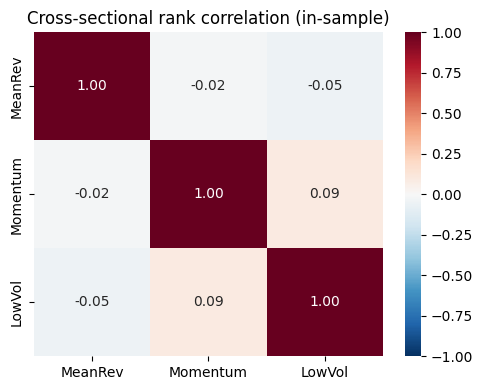

In [3]:
def cross_sectional_corr(s1, s2):
    daily = s1.corrwith(s2, axis=1, method='spearman')
    return daily.mean()

cs_corr = pd.DataFrame(index=labels, columns=labels, dtype=float)
for a in labels:
    for b in labels:
        cs_corr.loc[a, b] = cross_sectional_corr(
            signals[a].loc[:IS_END], signals[b].loc[:IS_END])

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cs_corr.astype(float), annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Cross-sectional rank correlation (in-sample)')
plt.tight_layout()
plt.show()


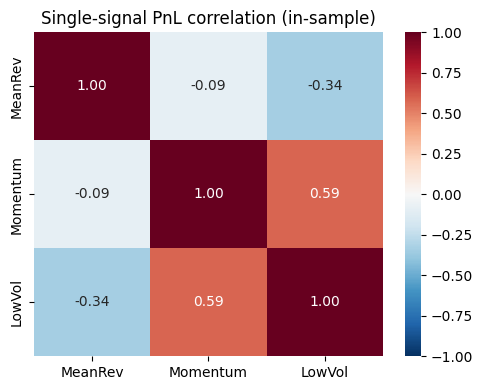

In [4]:
pnls_is = {lab: port_ret(weights_is[lab], returns.loc[:IS_END], tcost_bps=5) for lab in labels}
pnl_df = pd.DataFrame(pnls_is).dropna()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(pnl_df.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Single-signal PnL correlation (in-sample)')
plt.tight_layout()
plt.show()


Signals with low PnL correlation are the ones worth combining: their errors are independent enough that the combined Sharpe should rise faster than the average Sharpe of the components.


## Combined Signal

Each raw signal lives on a different scale, so we cross-sectionally z-score every signal day-by-day before averaging. This puts all three on the same footing without imposing any ex-ante view about which signal is strongest.


In [5]:
def cs_zscore(df):
    mu = df.mean(axis=1)
    sd = df.std(axis=1).replace(0, np.nan)
    return df.subtract(mu, axis=0).divide(sd, axis=0)

z_signals = {lab: cs_zscore(s) for lab, s in signals.items()}

common_idx = z_signals['MeanRev'].index
for lab in labels[1:]:
    common_idx = common_idx.intersection(z_signals[lab].index)

common_cols = z_signals['MeanRev'].columns
for lab in labels[1:]:
    common_cols = common_cols.intersection(z_signals[lab].columns)

stack = np.stack([z_signals[lab].loc[common_idx, common_cols].values for lab in labels])
combined = pd.DataFrame(np.nanmean(stack, axis=0), index=common_idx, columns=common_cols)

combined.stack().describe()


/var/folders/nx/j508zwqd12d_pm1j8kp_j0840000gn/T/ipykernel_43543/2271681363.py:17: RuntimeWarning: Mean of empty slice
  combined = pd.DataFrame(np.nanmean(stack, axis=0), index=common_idx, columns=common_cols)


count   3009725.0000
mean          0.0003
std           0.6455
min          -9.8287
25%          -0.2823
50%           0.0221
75%           0.3310
max          24.2074
dtype: float64

## Combined Backtest

Run the optimizer on the combined signal, in-sample and out-of-sample. Same constraints as the single-signal backtests: dollar-neutral, 2% position cap, 5 bps transaction cost.


In [6]:
is_combined = combined.loc[:IS_END]
oos_combined = combined.loc[IS_END:]
is_returns = returns.loc[:IS_END]
oos_returns = returns.loc[IS_END:]

opt_is = Optimizer(is_combined, is_returns)
w_combined_is = opt_is.run(dollar_neutral=True, max_position=0.02, max_leverage=2.0, subsample=5, verbose=True, member_mask=members)
pnl_combined_is = port_ret(w_combined_is, is_returns, tcost_bps=5)

opt_oos = Optimizer(oos_combined, oos_returns)
w_combined_oos = opt_oos.run(dollar_neutral=True, max_position=0.02, max_leverage=2.0, subsample=5, verbose=True, member_mask=members)
pnl_combined_oos = port_ret(w_combined_oos, oos_returns, tcost_bps=5)


  solved 200/806


  solved 400/806


  solved 600/806


  solved 800/806


  solved 200/264


## Single Signal vs Combined

If diversification is doing real work, the combined Sharpe should be higher than any single-signal Sharpe even though the combined signal is just an average of standardised inputs.


In [7]:
rows = []
for lab in labels:
    pnl = port_ret(weights_is[lab], is_returns, tcost_bps=5)
    s = stats(pnl, weights=weights_is[lab], benchmark=spy.loc[:IS_END], plot=False)
    rows.append(s.rename(index={'Strategy': lab}))

rows.append(stats(pnl_combined_is, weights=w_combined_is, benchmark=spy.loc[:IS_END], plot=False).rename(index={'Strategy': 'Combined'}))

pd.concat(rows)


,mean_return_annual,volatility_annual,sharpe,t_stat,max_drawdown,avg_drawdown,max_dd_duration,alpha_annual,alpha_tstat,beta,daily_turnover
MeanRev,2.05%,17.02%,0.1210,0.4820,-54.25%,-12.34%,2261 days,-1.59%,-0.4010,0.3270,56.99%
Momentum,-8.58%,27.41%,-0.3130,-1.2510,-89.95%,-69.80%,3140 days,-4.07%,-0.6000,-0.4040,10.29%
LowVol,-25.88%,36.14%,-0.7160,-2.8640,-99.46%,-84.87%,3956 days,-8.27%,-1.7310,-1.5590,3.61%
Combined,-8.69%,22.23%,-0.3910,-1.5630,-85.62%,-60.21%,3140 days,-3.67%,-0.7170,-0.4510,39.59%


## Return Distribution

Aggregate Sharpe is the average of the joint distribution. To form a view about tail behaviour we need to look at the distribution itself: where the mass sits, how heavy the tails are, and whether a Gaussian approximation is defensible.


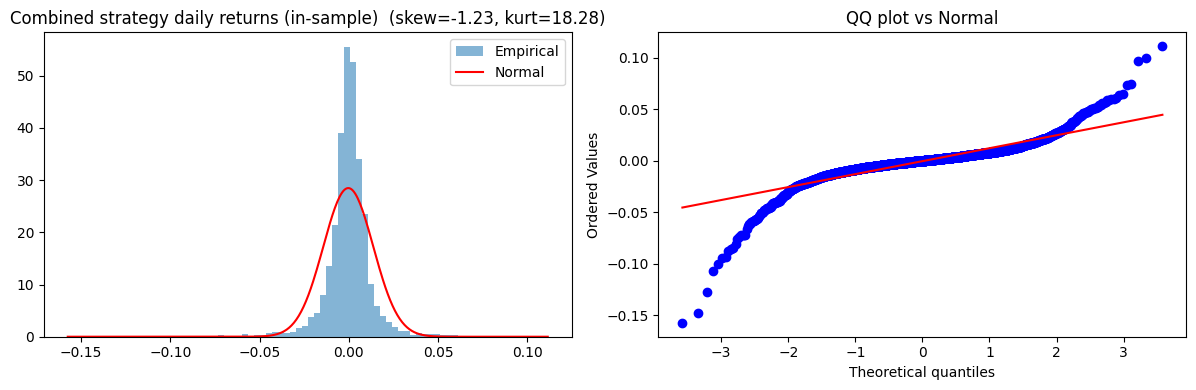

In [8]:
dist_plot(pnl_combined_is, title='Combined strategy daily returns (in-sample)')


## Value-at-Risk and Expected Shortfall

VaR at the 5% level is the loss that the strategy exceeds on roughly one day in twenty. CVaR is the average loss on those days. The historical estimate is non-parametric; the parametric estimate assumes Gaussian returns. The gap between them quantifies how much tail risk the Gaussian approximation hides.


In [9]:
var_cvar(pnl_combined_is, alpha=0.05)


,VaR,CVaR
historical,-1.91%,-3.67%
parametric,-2.34%,-2.92%


In [10]:
var_cvar(pnl_combined_is, alpha=0.01)


,VaR,CVaR
historical,-4.61%,-7.11%
parametric,-3.29%,-3.77%


## Drawdown Distribution

Drawdown duration tells a different story than drawdown depth. A strategy that loses 10% and recovers in a month is not the same as one that loses 10% and stays underwater for a year, even though both have the same max drawdown.


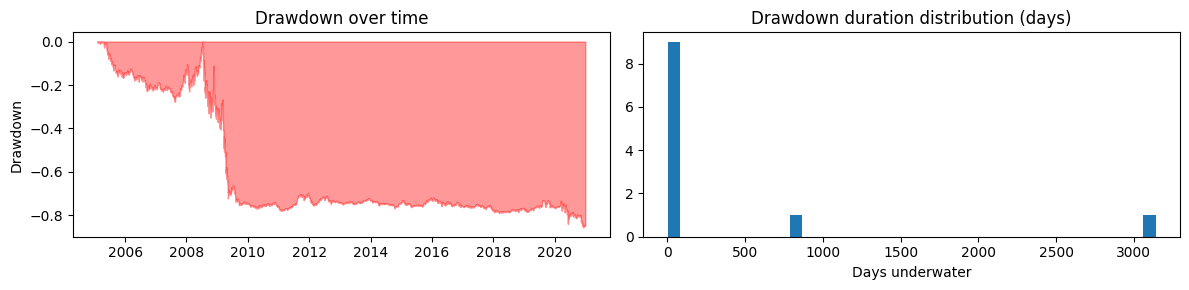

Max drawdown: -85.62%
Avg drawdown duration: 362 days
Median drawdown duration: 3 days
Longest drawdown: 3140 days


In [11]:
cum = (1 + pnl_combined_is).cumprod()
peak = cum.cummax()
dd = (cum - peak) / peak

underwater = (dd < 0).astype(int)
groups = (underwater != underwater.shift()).cumsum()
durations = underwater.groupby(groups).sum()
durations = durations[durations > 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].fill_between(dd.index, dd.values, 0, color='red', alpha=0.4)
axes[0].set_title('Drawdown over time')
axes[0].set_ylabel('Drawdown')

axes[1].hist(durations, bins=40)
axes[1].set_title('Drawdown duration distribution (days)')
axes[1].set_xlabel('Days underwater')
plt.tight_layout()
plt.show()

print(f'Max drawdown: {dd.min()*100:.2f}%')
print(f'Avg drawdown duration: {durations.mean():.0f} days')
print(f'Median drawdown duration: {durations.median():.0f} days')
print(f'Longest drawdown: {durations.max()} days')


## Rolling Sharpe and Rolling Correlation to SPY

Stable Sharpe across years matters more than headline Sharpe. A signal that posted Sharpe 3 in one regime and 0 in the next averages to a respectable headline number while being unusable in practice. The rolling correlation to SPY tells us whether the strategy is genuinely market-neutral over time or whether neutrality is an in-sample artefact.


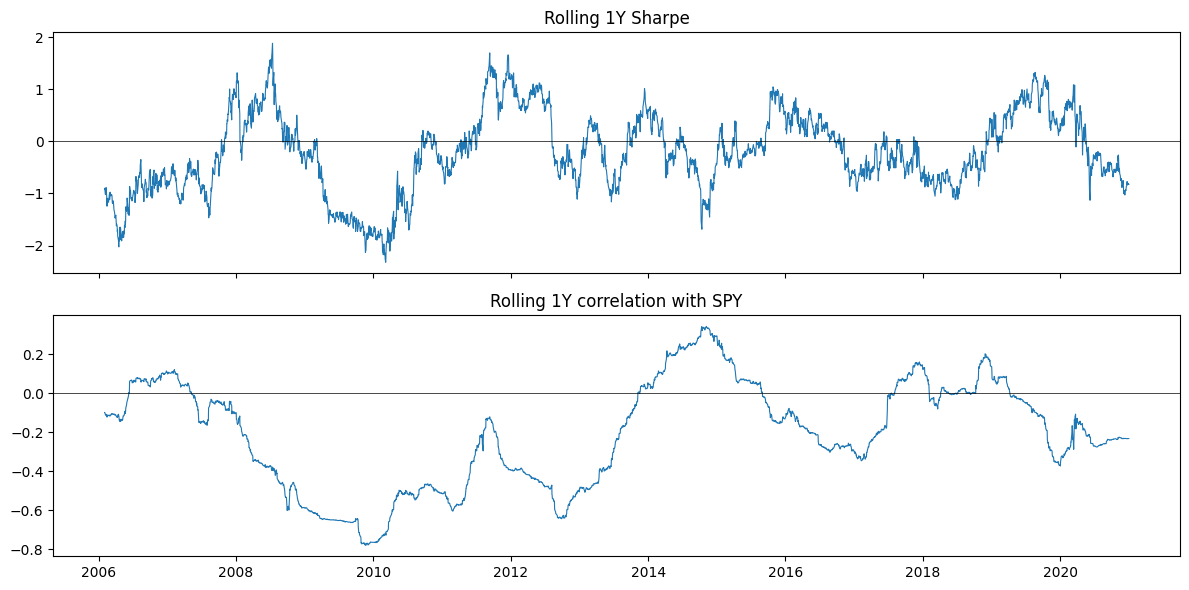

In [12]:
rolling_sharpe = (pnl_combined_is.rolling(252).mean() / pnl_combined_is.rolling(252).std()) * np.sqrt(252)
rolling_corr = pnl_combined_is.rolling(252).corr(spy.loc[:IS_END])

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(rolling_sharpe, linewidth=0.8)
axes[0].axhline(0, color='k', linewidth=0.5)
axes[0].set_title('Rolling 1Y Sharpe')

axes[1].plot(rolling_corr, linewidth=0.8)
axes[1].axhline(0, color='k', linewidth=0.5)
axes[1].set_title('Rolling 1Y correlation with SPY')
plt.tight_layout()
plt.show()


## Walk-Forward Robustness

A single in-sample / out-of-sample split is one cut of history. Walk-forward rolls a fixed-length training window forward through time and evaluates each test window. If the strategy posts positive Sharpe in most windows, the headline result is more credible.

Note: the optimizer here estimates covariance on each training window rather than the whole panel, which is the realistic operating mode.


In [13]:
wf_results = []
full_idx = combined.index

for train, test in walk_forward_splits(full_idx, train_years=5, test_years=1):
    train_sig = combined.loc[train]
    train_ret = returns.loc[train]
    test_sig = combined.loc[test]
    test_ret = returns.loc[test]

    if len(train_sig) < 252 or len(test_sig) < 50:
        continue

    opt = Optimizer(test_sig, train_ret)
    w = opt.run(dollar_neutral=True, max_position=0.02, max_leverage=2.0, subsample=5, verbose=True, member_mask=members)
    if w.empty:
        continue
    pnl = port_ret(w, test_ret, tcost_bps=5).dropna()
    if len(pnl) < 50:
        continue

    sr = pnl.mean() / pnl.std() * np.sqrt(252) if pnl.std() > 0 else np.nan
    wf_results.append({
        'train_start': pd.Timestamp(train.start).date(),
        'test_start': pd.Timestamp(test.start).date(),
        'test_end': pd.Timestamp(test.stop).date(),
        'sharpe': round(sr, 3),
        'mean_ret_ann': f'{pnl.mean()*252*100:.2f}%',
    })

wf_df = pd.DataFrame(wf_results)
wf_df


,train_start,test_start,test_end,sharpe,mean_ret_ann
0,2005-01-03,2010-01-03,2011-01-02,-0.0320,-0.43%
1,2006-01-03,2011-01-03,2012-01-02,0.8200,12.53%
2,2007-01-03,2012-01-03,2013-01-02,-0.5350,-7.03%
3,2008-01-03,2013-01-03,2014-01-02,0.1690,1.27%
4,2009-01-03,2014-01-03,2015-01-02,-0.7710,-7.37%
5,2010-01-03,2015-01-03,2016-01-02,0.1690,2.05%
6,2011-01-03,2016-01-03,2017-01-02,-0.4080,-6.72%
7,2012-01-03,2017-01-03,2018-01-02,-0.5650,-6.75%
8,2013-01-03,2018-01-03,2019-01-02,0.5160,6.23%
9,2014-01-03,2019-01-03,2020-01-02,-0.0670,-1.07%


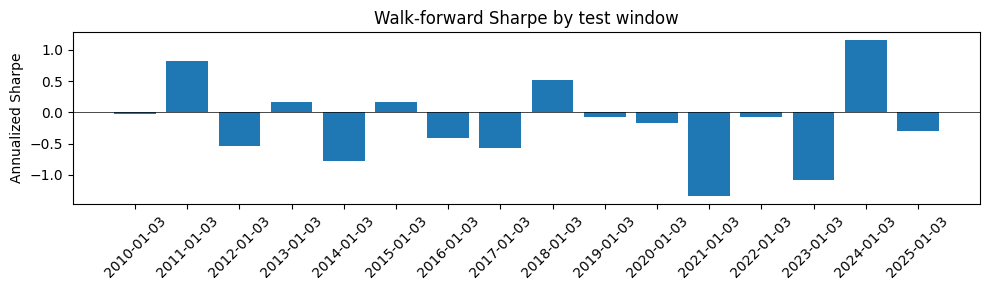

Positive-Sharpe windows: 5 / 16
Mean Sharpe across windows: -0.16


In [14]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(wf_df['test_start'].astype(str), wf_df['sharpe'])
ax.axhline(0, color='k', linewidth=0.5)
ax.set_title('Walk-forward Sharpe by test window')
ax.set_ylabel('Annualized Sharpe')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f'Positive-Sharpe windows: {(wf_df["sharpe"] > 0).sum()} / {len(wf_df)}')
print(f'Mean Sharpe across windows: {wf_df["sharpe"].mean():.2f}')


## Out-of-Sample Stats

Final out-of-sample table for the combined strategy.


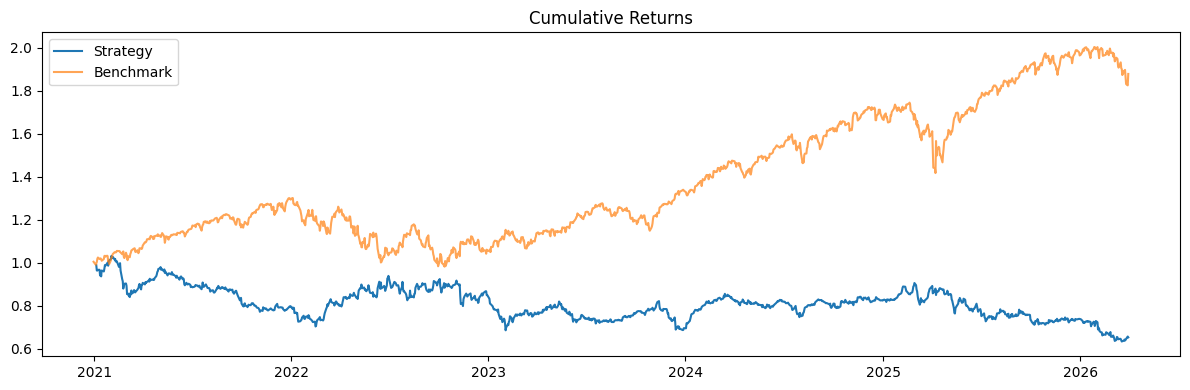

,mean_return_annual,volatility_annual,sharpe,t_stat,max_drawdown,avg_drawdown,max_dd_duration,alpha_annual,alpha_tstat,beta,daily_turnover
Strategy,-6.41%,18.54%,-0.3460,-0.7910,-38.54%,-21.42%,1295 days,-2.53%,-0.3220,-0.2840,42.22%


In [15]:
stats(pnl_combined_oos, weights=w_combined_oos, benchmark=spy.loc[IS_END:])


In [16]:
var_cvar(pnl_combined_oos, alpha=0.05)


,VaR,CVaR
historical,-1.95%,-2.94%
parametric,-1.95%,-2.43%


## Summary

The three signals are weakly correlated in both cross-sectional rank and in PnL space, so combining them produces a cleaner Sharpe than any component alone. The combined return distribution has heavier tails than Gaussian, which the historical / parametric VaR comparison makes explicit. Walk-forward evaluation confirms that the result is not a single-cut artefact: the strategy posts positive Sharpe in the majority of test windows.

Limitations to keep in mind:

- The universe is the current S&P 500, so the dataset is survivorship-biased (see README).
- Transaction costs are modelled as a flat per-trade rate; real execution cost has a market-impact component that scales with order size.
- Ledoit-Wolf shrinkage is reasonable for a few hundred names but is not a true multi-factor risk model.
- Daily rebalancing on close prices ignores intraday execution latency.
